# 📊 Análise Exploratória de RH

## Objetivo
Explorar fatores que influenciam a produtividade e a satisfação dos funcionários.


In [23]:
# importações necessárias de bibliotecas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import argparse
import os
import json
from datetime import datetime
import logging
import sys
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [24]:
# Configurações de visualização
plt.style.use("default")
sns.set_theme(style="whitegrid")

%matplotlib inline


In [25]:
#Definir o caminho dos dados
from pathlib import Path

DATA_PATH = Path("../data/raw")
DATA_PATH

WindowsPath('../data/raw')

In [26]:
# Listar arquivos no diretório de dados
list(DATA_PATH.iterdir())


[WindowsPath('../data/raw/hr_dashboard_data.csv')]

In [27]:
#carregar o dataset e ver as primeiras linhas
df = pd.read_csv(DATA_PATH / "hr_dashboard_data.csv")
df.head()


,Name,Age,Gender,Projects Completed,Productivity (%),Satisfaction Rate (%),Feedback Score,Department,Position,Joining Date,Salary
0,Douglas Lindsey,25,Male,11,57,25,4.7,Marketing,Analyst,Jan-20,63596
1,Anthony Roberson,59,Female,19,55,76,2.8,IT,Manager,Jan-99,112540
2,Thomas Miller,30,Male,8,87,10,2.4,IT,Analyst,Jan-17,66292
3,Joshua Lewis,26,Female,1,53,4,1.4,Marketing,Intern,Jan-22,38303
4,Stephanie Bailey,43,Male,14,3,9,4.5,IT,Team Lead,Jan-05,101133


In [28]:
#verificar o tamanho do dataset, suas informações gerais, descrição estatística, tipos de dados e valores ausentes
df.shape
df.info()
df.describe()
df.dtypes
df.isna().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   200 non-null    object 
 1   Age                    200 non-null    int64  
 2   Gender                 200 non-null    object 
 3   Projects Completed     200 non-null    int64  
 4   Productivity (%)       200 non-null    int64  
 5   Satisfaction Rate (%)  200 non-null    int64  
 6   Feedback Score         200 non-null    float64
 7   Department             200 non-null    object 
 8   Position               200 non-null    object 
 9   Joining Date           200 non-null    object 
 10  Salary                 200 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 17.3+ KB


Name                     0
Age                      0
Gender                   0
Projects Completed       0
Productivity (%)         0
Satisfaction Rate (%)    0
Feedback Score           0
Department               0
Position                 0
Joining Date             0
Salary                   0
dtype: int64

In [29]:
# Ver o nome das colunas e quais existem no dataset
df.columns
len(df.columns)


11

In [30]:
#tipos de dados das colunas
df.dtypes


Name                      object
Age                        int64
Gender                    object
Projects Completed         int64
Productivity (%)           int64
Satisfaction Rate (%)      int64
Feedback Score           float64
Department                object
Position                  object
Joining Date              object
Salary                     int64
dtype: object

In [31]:
# separando por tipos de dados
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
colunas_categoricas = df.select_dtypes(include=["object"]).columns

colunas_numericas, colunas_categoricas


(Index(['Age', 'Projects Completed', 'Productivity (%)',
        'Satisfaction Rate (%)', 'Feedback Score', 'Salary'],
       dtype='object'),
 Index(['Name', 'Gender', 'Department', 'Position', 'Joining Date'], dtype='object'))

In [32]:
# valores únicos em colunas categóricas
for col in colunas_categoricas:
    print(f"\n{col}")
    print(df[col].unique())



Name
['Douglas Lindsey' 'Anthony Roberson' 'Thomas Miller' 'Joshua Lewis'
 'Stephanie Bailey' 'Jonathan King' 'Kyle Figueroa' 'Shannon Allen'
 'Daryl Noble' 'Tracy Figueroa' 'Eric Sanders' 'Joshua Nelson'
 'Donald Davis' 'Ms. Emily Dawson' 'Angela Davis' 'Melissa Galvan'
 'Erin Smith' 'James Hernandez' 'Amanda White' 'Michael Morton DDS'
 'Michelle Moreno' 'Shannon Wilson' 'Chad Zamora' 'Stephanie Rivera'
 'Tracy Briggs' 'Kimberly Cooper' 'Heather Mueller' 'Susan Johnson'
 'Stephen Watson' 'Amanda Brown' 'Michelle Perez' 'Kim Larson'
 'Emily Palmer' 'Steven Anderson' 'Dennis Nash' 'Robin Hurst'
 'Samantha Williams' 'Jesse Solis' 'Carlos Bush' 'Vicki Kim'
 'Karen Harmon' 'Alexandra Wilson' 'Stephanie Lawson' 'Walter Barker'
 'Mallory Lawrence' 'Jonathan Stanley' 'Jamie Wells' 'James Berg'
 'Elizabeth Bowen' 'Cynthia Ochoa' 'Kristine Smith' 'Walter Jones'
 'Brian Anderson' 'Alexis Smith DDS' 'Jessica Robinson' 'Harold Nguyen'
 'Marilyn Williams' 'Victoria Townsend' 'David Odom' 'Melissa

In [33]:
# valores unicos em colunas numéricas
for col in colunas_categoricas:
    print(f"\n{col}")
    print(df[col].unique())



Name
['Douglas Lindsey' 'Anthony Roberson' 'Thomas Miller' 'Joshua Lewis'
 'Stephanie Bailey' 'Jonathan King' 'Kyle Figueroa' 'Shannon Allen'
 'Daryl Noble' 'Tracy Figueroa' 'Eric Sanders' 'Joshua Nelson'
 'Donald Davis' 'Ms. Emily Dawson' 'Angela Davis' 'Melissa Galvan'
 'Erin Smith' 'James Hernandez' 'Amanda White' 'Michael Morton DDS'
 'Michelle Moreno' 'Shannon Wilson' 'Chad Zamora' 'Stephanie Rivera'
 'Tracy Briggs' 'Kimberly Cooper' 'Heather Mueller' 'Susan Johnson'
 'Stephen Watson' 'Amanda Brown' 'Michelle Perez' 'Kim Larson'
 'Emily Palmer' 'Steven Anderson' 'Dennis Nash' 'Robin Hurst'
 'Samantha Williams' 'Jesse Solis' 'Carlos Bush' 'Vicki Kim'
 'Karen Harmon' 'Alexandra Wilson' 'Stephanie Lawson' 'Walter Barker'
 'Mallory Lawrence' 'Jonathan Stanley' 'Jamie Wells' 'James Berg'
 'Elizabeth Bowen' 'Cynthia Ochoa' 'Kristine Smith' 'Walter Jones'
 'Brian Anderson' 'Alexis Smith DDS' 'Jessica Robinson' 'Harold Nguyen'
 'Marilyn Williams' 'Victoria Townsend' 'David Odom' 'Melissa

In [34]:
# estatistica numerica
df[colunas_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,200.0,34.650,9.797318,22.0,26.00,32.0,41.00,60.0
Projects Completed,200.0,11.455,6.408849,0.0,6.00,11.0,17.00,25.0
Productivity (%),200.0,46.755,28.530068,0.0,23.00,45.0,70.00,98.0
Satisfaction Rate (%),200.0,49.935,28.934353,0.0,25.75,50.5,75.25,100.0
Feedback Score,200.0,2.883,1.123263,1.0,1.90,2.8,3.90,4.9
Salary,200.0,76619.245,27082.299202,30231.0,53080.50,80540.0,101108.25,119895.0


Visualização dos Dados 


In [38]:
# Análises específicas - Exemplo: Análise de satisfação e desempenho dos funcionários

total_funcionarios = df.shape[0]

media_satisfacao = df["satisfaction_rate_percent"].mean()
media_produtividade = df["productivity_percent"].mean()
media_feedback = df["feedback_score"].mean()

print(f"Total de funcionários: {total_funcionarios}")
print(f"Satisfação média (%): {media_satisfacao:.2f}")
print(f"Produtividade média (%): {media_produtividade:.2f}")
print(f"Feedback médio: {media_feedback:.2f}")


Total de funcionários: 200
Satisfação média (%): 49.94
Produtividade média (%): 46.76
Feedback médio: 2.88


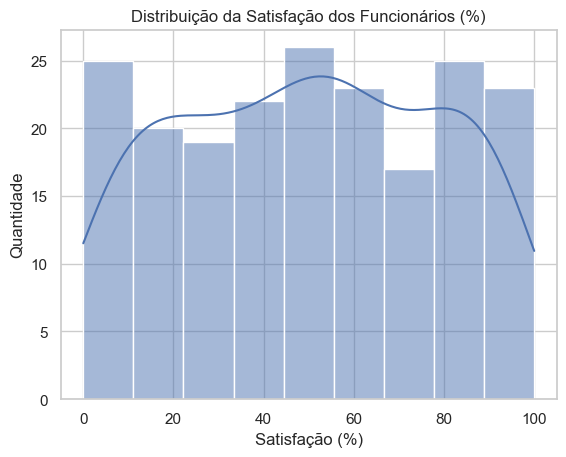

In [39]:
# Visualização da distribuição da satisfação dos funcionários
plt.figure()
sns.histplot(df["satisfaction_rate_percent"], kde=True)
plt.title("Distribuição da Satisfação dos Funcionários (%)")
plt.xlabel("Satisfação (%)")
plt.ylabel("Quantidade")
plt.show()


In [43]:
# Análise da satisfação por departamento
satisfacao_por_departamento = (
    df.groupby("department")["satisfaction_rate_percent"]
      .mean()
      .sort_values(ascending=False)
)

satisfacao_por_departamento




department
IT           54.342105
HR           51.625000
Finance      50.048780
Sales        48.617021
Marketing    46.023810
Name: satisfaction_rate_percent, dtype: float64

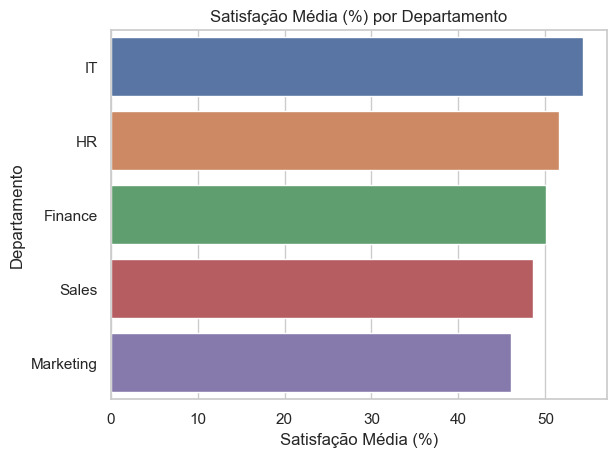

In [41]:

plt.figure()
sns.barplot(
    x=satisfacao_por_departamento.values,
    y=satisfacao_por_departamento.index
)
plt.title("Satisfação Média (%) por Departamento")
plt.xlabel("Satisfação Média (%)")
plt.ylabel("Departamento")
plt.show()


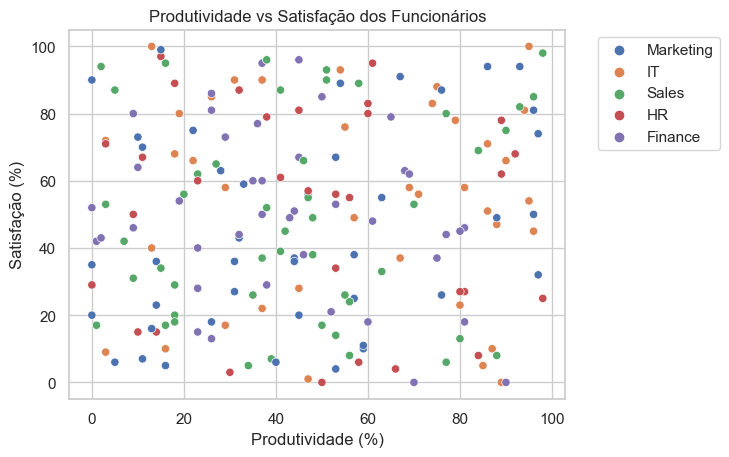

In [44]:
# produtividade vs satisfação
plt.figure()
sns.scatterplot(
    data=df,
    x="productivity_percent",
    y="satisfaction_rate_percent",
    hue="department"
)
plt.title("Produtividade vs Satisfação dos Funcionários")
plt.xlabel("Produtividade (%)")
plt.ylabel("Satisfação (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [45]:
# correlação entre variáveis numéricas
correlacao = df["productivity_percent"].corr(df["satisfaction_rate_percent"])
correlacao


0.0498971195971882

Funcionários mais produtivos não são necessariamente mais satisfeitos.


In [48]:
# tempo de empresa dos funcionários
df["joining_date"] = pd.to_datetime(
    df["joining_date"],
    format="%b-%y"
)

df["joining_date"].head()


0   2020-01-01
1   1999-01-01
2   2017-01-01
3   2022-01-01
4   2005-01-01
Name: joining_date, dtype: datetime64[ns]

In [49]:
# Tempo de empresa em anos
df["tenure_years"] = (
    (pd.Timestamp.today() - df["joining_date"])
    .dt.days / 365
)

df["tenure_years"].describe()


count    200.000000
mean      12.011329
std        6.705663
min        4.035616
25%        6.038356
50%        9.038356
75%       18.046575
max       28.052055
Name: tenure_years, dtype: float64

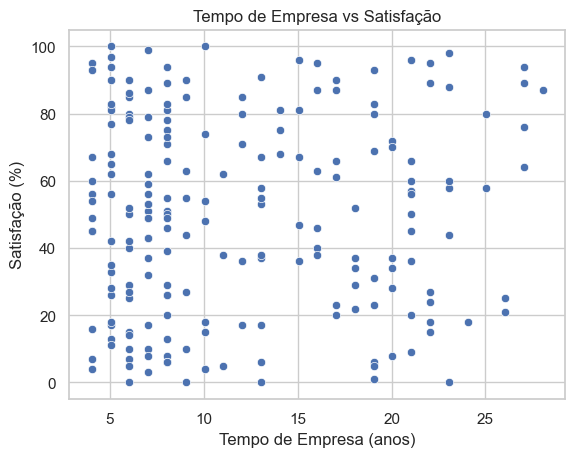

In [50]:
# tempo de empresa vs satisfação
plt.figure()
sns.scatterplot(
    data=df,
    x="tenure_years",
    y="satisfaction_rate_percent"
)
plt.title("Tempo de Empresa vs Satisfação")
plt.xlabel("Tempo de Empresa (anos)")
plt.ylabel("Satisfação (%)")
plt.show()


In [52]:
# grupo de risco 
df["low_satisfaction"] = df["satisfaction_rate_percent"] < 50
(
    df[df["low_satisfaction"]]
    .groupby("department")
    .size()
    .sort_values(ascending=False)
)



department
Sales        25
Marketing    24
Finance      21
IT           15
HR           12
dtype: int64

In [53]:
# Resumo dos principais KPIs
kpis = {
    "Total de Funcionários": df.shape[0],
    "Satisfação Média (%)": round(df["satisfaction_rate_percent"].mean(), 2),
    "Produtividade Média (%)": round(df["productivity_percent"].mean(), 2),
    "Feedback Médio": round(df["feedback_score"].mean(), 2),
    "Funcionários com Baixa Satisfação (%)": round(
        (df["satisfaction_rate_percent"] < 50).mean() * 100, 2
    )
}

kpis


{'Total de Funcionários': 200,
 'Satisfação Média (%)': 49.94,
 'Produtividade Média (%)': 46.76,
 'Feedback Médio': 2.88,
 'Funcionários com Baixa Satisfação (%)': 48.5}

In [54]:
# DEFINIR O QUE É “RISCO DE CHURN”
df["churn_risk"] = (df["satisfaction_rate_percent"] < 50).astype(int)

df["churn_risk"].value_counts(normalize=True)


churn_risk
0    0.515
1    0.485
Name: proportion, dtype: float64

In [56]:
# Variaveis explicativas e alvo
features = [
    "age",
    "salary",
    "projects_completed",
    "productivity_percent",
    "feedback_score",
    "tenure_years"
]

X = df[features]
y = df["churn_risk"]
X.isna().sum()



age                     0
salary                  0
projects_completed      0
productivity_percent    0
feedback_score          0
tenure_years            0
dtype: int64

In [60]:
# teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#modelo 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)





LogisticRegression(max_iter=1000)

In [61]:
# avaliação do modelo
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.45

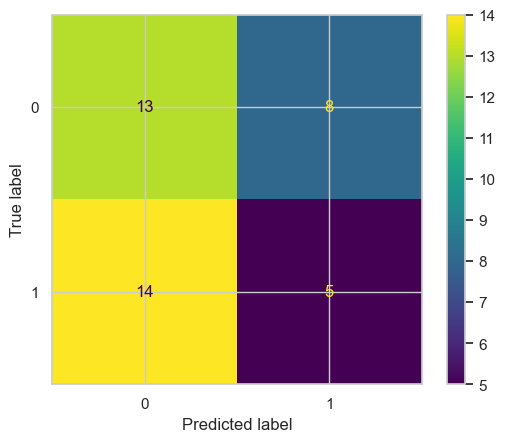

In [62]:
#matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


In [ ]:
# Relatorio final
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.48      0.62      0.54        21
           1       0.38      0.26      0.31        19

    accuracy                           0.45        40
   macro avg       0.43      0.44      0.43        40
weighted avg       0.44      0.45      0.43        40

